### Pacotes importados

In [1]:
using LinearAlgebra
using Printf

## Chapter 8: Quasi-Newton methods

### Algorithm 8.1: Finite difference Newton's method: one variable

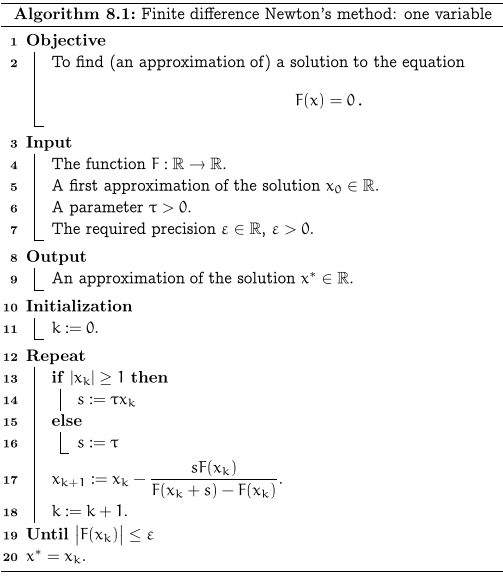

Example: $F(x)=x^2-2$. Run the example with $x_0=2$ and $\tau=10^{-7}$

In [3]:
F81(x) = x^2 - 2
x0 = 2.0
T1 = 1e-7
eps = 1e-15

let xk = x0, k = 0
    println("k   | xk                   | F(xk)")
    while abs(F81(xk)) > eps
        @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F81(xk))
        s = abs(xk) >= 1 ? T1 * xk : T1
        df_aprox = (F81(xk + s) - F81(xk)) / s
        xk = xk - F81(xk) / df_aprox
        k += 1
    end
    @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F81(xk))
end

k   | xk                   | F(xk)
0   | 2.000000000000000    | 2.000000000000000e+00
1   | 1.500000025271950    | 2.500000758158514e-01
2   | 1.416666672239940    | 6.944460235386085e-03
3   | 1.414215686408005    | 6.007682464392872e-06
4   | 1.414213562374796    | 4.810818410305728e-12
5   | 1.414213562373095    | 4.440892098500626e-16


Run the example with $x_0=2$ and $\tau=0.1$

In [4]:
T2 = 0.1
let xk = x0, k = 0
    println("k   | xk                   | F(xk)")
    while abs(F81(xk)) > eps
        @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F81(xk))
        s = abs(xk) >= 1 ? T2 * xk : T2
        df_aprox = (F81(xk + s) - F81(xk)) / s
        xk = xk - F81(xk) / df_aprox
        k += 1
    end
    @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F81(xk))
end

k   | xk                   | F(xk)
0   | 2.000000000000000    | 2.000000000000000e+00
1   | 1.523809523809524    | 3.219954648526087e-01
2   | 1.423185941043084    | 2.545822278268872e-02
3   | 1.414667754571282    | 1.284855823753706e-03
4   | 1.414235260012350    | 6.137066219880083e-05
5   | 1.414214595752532    | 2.922839497099261e-06
6   | 1.414213611581999    | 1.391838018172109e-07
7   | 1.414213564716377    | 6.627801862890692e-09
8   | 1.414213562484680    | 3.156097605483410e-10
9   | 1.414213562378408    | 1.502842295053597e-11
10  | 1.414213562373348    | 7.154277170684509e-13
11  | 1.414213562373107    | 3.419486915845482e-14
12  | 1.414213562373096    | 1.332267629550188e-15
13  | 1.414213562373095    | 4.440892098500626e-16


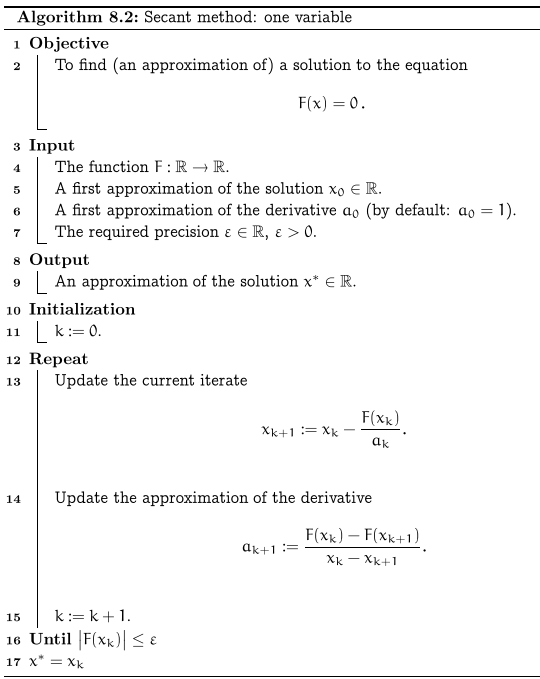

Example: $F(x)=x^2-2$, with $x_0=2$ and $a_0=1$

In [5]:
let xk = 2.0, ak = 1.0, k = 0
    println("k   | xk                   | F(xk)")
    while abs(F81(xk)) > eps
        @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F81(xk))
        x_next = xk - F81(xk) / ak
        ak = (F81(xk) - F81(x_next)) / (xk - x_next)
        xk = x_next
        k += 1
    end
    @printf("%-3d | %-20.15f | %-20.15e\n", k, xk, F81(xk))
end# codigo aqui

k   | xk                   | F(xk)
0   | 2.000000000000000    | 2.000000000000000e+00
1   | 0.000000000000000    | -2.000000000000000e+00
2   | 1.000000000000000    | -1.000000000000000e+00
3   | 2.000000000000000    | 2.000000000000000e+00
4   | 1.333333333333333    | -2.222222222222219e-01
5   | 1.400000000000000    | -3.999999999999959e-02
6   | 1.414634146341463    | 1.189767995240842e-03
7   | 1.414211438474870    | -6.007286838860537e-06
8   | 1.414213562057320    | -8.931455575122982e-10
9   | 1.414213562373095    | 8.881784197001252e-16


### Algorithm 8.3: finite difference Newton's method: $n$ variables

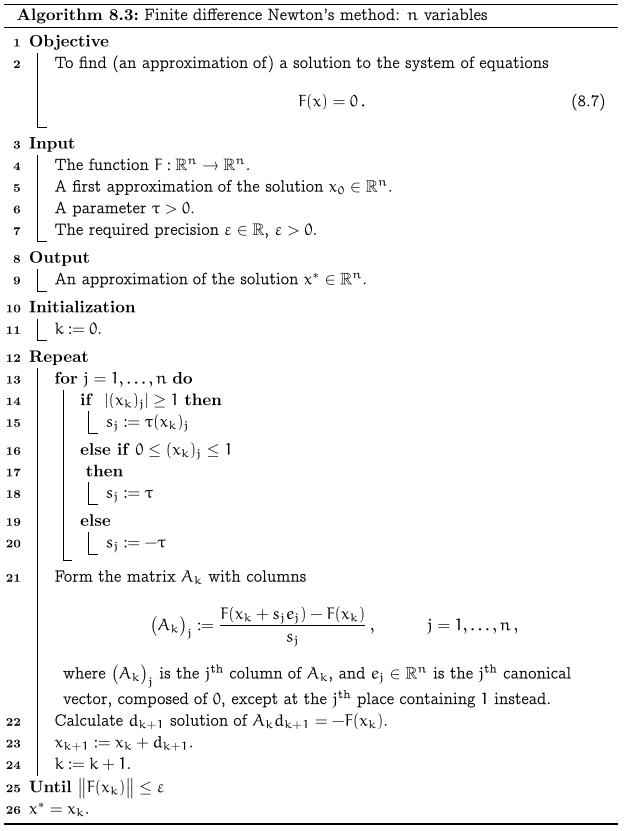

Example: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$. Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=10^{-7}$

In [6]:
F83(x) = [(x[1]+1)^2 + x[2] - 2, exp(x[1]) + x[2]^3 - 2]
x0_n = [1.0, 1.0]
T_n1 = 1e-7

let xk = Float64.(x0_n), k = 0
    while norm(F83(xk)) > eps
        fk = F83(xk)
        @printf("Iter %d: ||F(x)|| = %.2e\n", k, norm(fk))
        Ak = zeros(2, 2)
        for j in 1:2
            sj = abs(xk[j]) >= 1 ? T_n1 * xk[j] : T_n1
            ej = [j == i ? 1.0 : 0.0 for i in 1:2]
            Ak[:, j] = (F83(xk + sj * ej) - fk) / sj
        end
        xk = xk + (Ak \ -fk)
        k += 1
    end
    @printf("Final: ||F(x)|| = %.2e em %d iterações\n", norm(F83(xk)), k)
end

Iter 0: ||F(x)|| = 3.46e+00
Iter 1: ||F(x)|| = 9.43e-01
Iter 2: ||F(x)|| = 8.21e-02
Iter 3: ||F(x)|| = 1.17e-03
Iter 4: ||F(x)|| = 5.90e-07
Iter 5: ||F(x)|| = 2.30e-13
Final: ||F(x)|| = 4.44e-16 em 6 iterações


Run the example with $x_0= \left(\begin{array}{c} 1 \\ 1 \end{array}\right)$ and $\tau=0.1$

In [7]:
T_n2 = 0.1
let xk = Float64.(x0_n), k = 0
    while norm(F83(xk)) > eps
        fk = F83(xk)
        @printf("Iter %d: ||F(x)|| = %.2e\n", k, norm(fk))
        Ak = zeros(2, 2)
        for j in 1:2
            sj = abs(xk[j]) >= 1 ? T_n2 * xk[j] : T_n2
            ej = [j == i ? 1.0 : 0.0 for i in 1:2]
            Ak[:, j] = (F83(xk + sj * ej) - fk) / sj
        end
        xk = xk + (Ak \ -fk)
        k += 1
    end
    @printf("Final: ||F(x)|| = %.2e em %d iterações\n", norm(F83(xk)), k)
end

Iter 0: ||F(x)|| = 3.46e+00
Iter 1: ||F(x)|| = 1.01e+00
Iter 2: ||F(x)|| = 1.42e-01
Iter 3: ||F(x)|| = 1.38e-02
Iter 4: ||F(x)|| = 1.39e-03
Iter 5: ||F(x)|| = 1.48e-04
Iter 6: ||F(x)|| = 1.60e-05
Iter 7: ||F(x)|| = 1.75e-06
Iter 8: ||F(x)|| = 1.92e-07
Iter 9: ||F(x)|| = 2.11e-08
Iter 10: ||F(x)|| = 2.32e-09
Iter 11: ||F(x)|| = 2.55e-10
Iter 12: ||F(x)|| = 2.80e-11
Iter 13: ||F(x)|| = 3.07e-12
Iter 14: ||F(x)|| = 3.38e-13
Iter 15: ||F(x)|| = 3.72e-14
Iter 16: ||F(x)|| = 3.79e-15
Final: ||F(x)|| = 4.97e-16 em 17 iterações


### Algorithm 8.4: secant method: $n$ variables

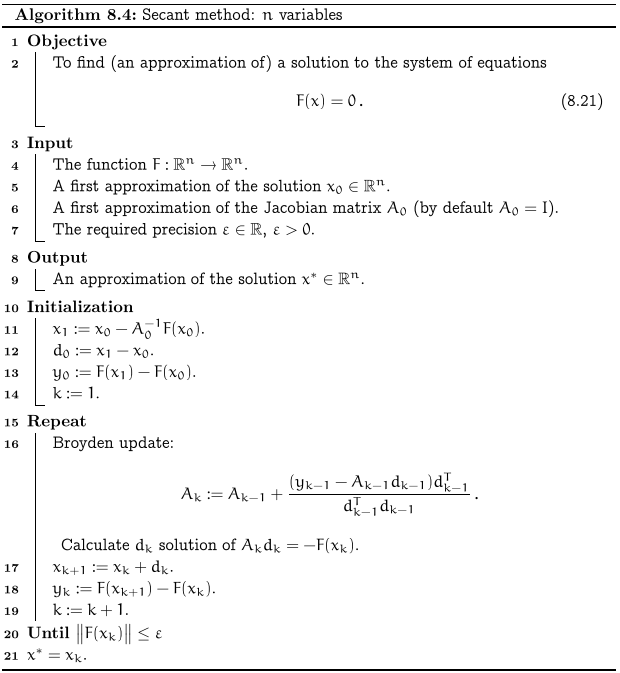

Example 7.11: $F(x)=\left(\begin{array}{c}(x_1+1)^2+ x_2^2 - 2 \\ e^{x_1} + x_2^3 - 2 \end{array}\right)$, $x_0=\left(\begin{array}{c} 1 \\ 1 \end{array}\right)$


In [8]:
let xk = [1.0, 1.0], Ak = Matrix(1.0I, 2, 2), k = 1
    # Inicialização do Passo 11
    x_next = xk - Ak \ F83(xk)
    dk = x_next - xk
    yk = F83(x_next) - F83(xk)
    xk = x_next
    
    println("k   | ||F(xk)||")
    while norm(F83(xk)) > eps
        @printf("%-3d | %.15e\n", k, norm(F83(xk)))
        # Atualização de Broyden
        Ak = Ak + ((yk - Ak * dk) * dk') / (dk' * dk)
        dk = Ak \ -F83(xk)
        x_next = xk + dk
        yk = F83(x_next) - F83(xk)
        xk = x_next
        k += 1
    end
    @printf("%-3d | %.15e\n", k, norm(F83(xk)))
end

k   | ||F(xk)||
1   | 2.819365449674791e+00
2   | 2.056957229412848e+00
3   | 3.238190863113246e+01
4   | 1.925933751378509e+00
5   | 6.655007581362720e-01
6   | 3.813389604886933e-01
7   | 3.892830521345433e-01
8   | 3.395970606672651e-01
9   | 3.560553413136363e+01
10  | 3.383837082375061e-01
11  | 3.403317816373655e-01
12  | 1.019284655382196e+02
13  | 3.328285232348319e-01
14  | 3.336487106982365e-01
15  | 2.244230288016821e+00
16  | 3.816787959863811e-01
17  | 5.010126493146612e-01
18  | 6.493322787517691e-01
19  | 1.991997300302576e+01
20  | 5.198377819778498e-01
21  | 4.307043106668775e-01
22  | 3.898679479641260e-01
23  | 8.487249268964335e+01
24  | 4.071487217369433e-01
25  | 4.187187055872738e-01
26  | 2.554457286452740e+00
27  | 5.265825621131027e-01
28  | 5.853166882397398e-01
29  | 2.805388376897569e+00
30  | 2.600467445591099e-01
31  | 4.164774419154567e-01
32  | 1.548823120288839e-01
33  | 3.922095736343438e-02
34  | 6.442854642230945e-03
35  | 1.908831000796901e-03
36  